# Exploration

We explore the dataset to better understand its structure, detect potential issues, and build ideas for preprocessing and experiments that support a good anomaly detection system.

We start with loading MNIST dataset and splitting both the training and test sets into the following subsets:

- `train/8`: training samples with label `8`
- `train/4`: training samples with label `4`
- `train/rest`: all remaining training samples
- `test/8`: test samples with label `8`
- `test/4`: test samples with label `4`
- `test/rest`: all remaining test samples

We use only `train/rest` `test/8` and `test/4` where digits `8` and `4` are treated as anomalous. We also reserve `test/4` for the final evaluation.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random
import torch

from common.config import MNIST_RAW_PATH, FIGS_DIR, SEED

SAVE_DIR = FIGS_DIR / "exploration"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# set seeds
from numpy.random import RandomState, SeedSequence, MT19937

random.seed(SEED)
rs = RandomState(MT19937(SeedSequence(SEED)))

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
mnist = np.load(MNIST_RAW_PATH)
print(f"Files: {mnist.files}")
for file in mnist.files:
    print(f"{file} = {mnist[file].shape}")

Files: ['train_data', 'test_data', 'train_labels', 'test_labels']
train_data = (55000, 784)
test_data = (10000, 784)
train_labels = (55000, 10)
test_labels = (10000, 10)


In [4]:
# Split train/test into target 8, target 4, and the rest
x_train = torch.from_numpy(mnist["train_data"]).float()
y_train = torch.from_numpy(mnist["train_labels"]).float()
x_test = torch.from_numpy(mnist["test_data"]).float()
y_test = torch.from_numpy(mnist["test_labels"]).float()

train_4_mask = y_train[:, 4] == 1
train_8_mask = y_train[:, 8] == 1
train_rest_mask = ~(train_8_mask | train_4_mask)

test_4_mask = y_test[:, 4] == 1
test_8_mask = y_test[:, 8] == 1
test_rest_mask = ~(test_8_mask | test_4_mask)

train_8 = (x_train[train_8_mask], y_train[train_8_mask])
train_4 = (x_train[train_4_mask], y_train[train_4_mask])
train_rest = (x_train[train_rest_mask], y_train[train_rest_mask])

test_8 = (x_test[test_8_mask], y_test[test_8_mask])
test_4 = (x_test[test_4_mask], y_test[test_4_mask])
test_rest = (x_test[test_rest_mask], y_test[test_rest_mask])

print("Train splits:")
print(f"\ttrain_4:    \tX={train_4[0].shape}, y={train_4[1].shape}")
print(f"\ttrain_8:    \tX={train_8[0].shape}, y={train_8[1].shape}")
print(f"\ttrain_rest: \tX={train_rest[0].shape}, y={train_rest[1].shape}")

print("\nTest splits:")
print(f"\ttest_4:    \tX={test_4[0].shape}, y={test_4[1].shape}")
print(f"\ttest_8:    \tX={test_8[0].shape}, y={test_8[1].shape}")
print(f"\ttest_rest: \tX={test_rest[0].shape}, y={test_rest[1].shape}")

Train splits:
	train_4:    	X=torch.Size([5307, 784]), y=torch.Size([5307, 10])
	train_8:    	X=torch.Size([5389, 784]), y=torch.Size([5389, 10])
	train_rest: 	X=torch.Size([44304, 784]), y=torch.Size([44304, 10])

Test splits:
	test_4:    	X=torch.Size([982, 784]), y=torch.Size([982, 10])
	test_8:    	X=torch.Size([974, 784]), y=torch.Size([974, 10])
	test_rest: 	X=torch.Size([8044, 784]), y=torch.Size([8044, 10])


We visualize 9 samples from each subset that is going to be used.

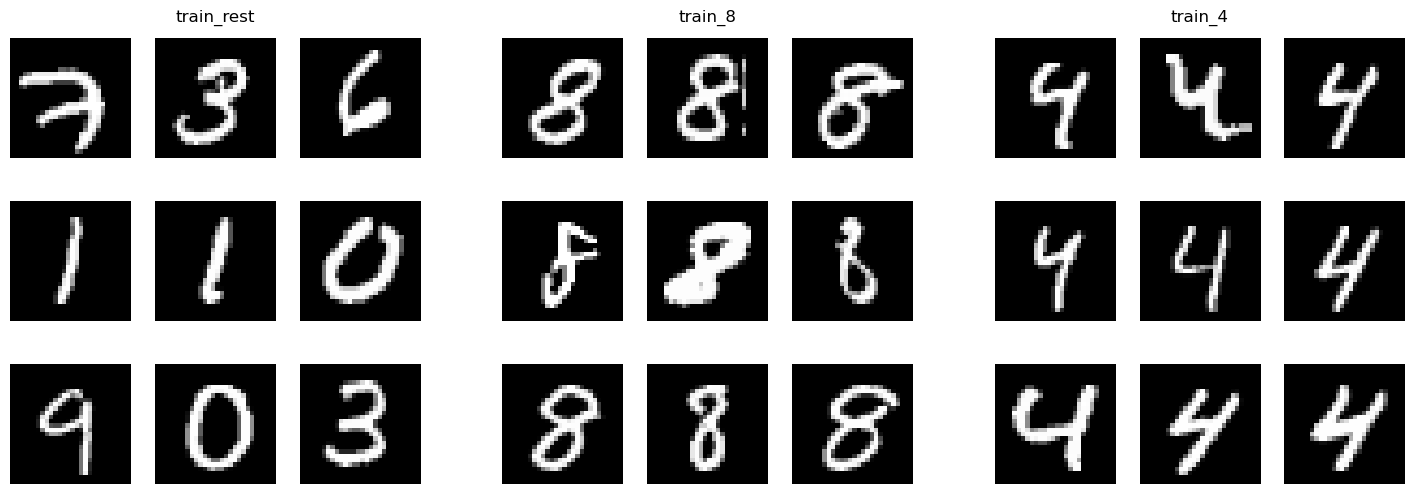

In [5]:
plot_datasets = [
    ("train_rest", train_rest),
    ("train_8", train_8),
    ("train_4", train_4),
]

fig = plt.figure(figsize=(18, 6))
outer = fig.add_gridspec(1, 3)

for col, (name, data) in enumerate(plot_datasets):
    inner = outer[col].subgridspec(3, 3)

    for i in range(9):
        row, col_in = divmod(i, 3)
        ax = fig.add_subplot(inner[row, col_in])

        img = data[0][i].reshape(28, 28)
        label = data[1][i].argmax().item()

        ax.imshow(img, cmap="gray")
        # ax.set_title(f"target: {label}", fontsize=9)
        ax.axis("off")

    # title for each dataset
    title_ax = fig.add_subplot(outer[col])
    title_ax.set_title(name)
    title_ax.axis("off")

plt.show()
fig.savefig(SAVE_DIR / "subsets_samples.png", dpi=300, bbox_inches="tight")

## t-SNE

We build a 2D t-SNE representation in order to see the natural clustering in the data.

Computing t-SNE...
[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.002s...
[t-SNE] Computed neighbors for 10000 samples in 1.720s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 2.213647
[t-SNE] KL divergence after 250 iterations with early exaggeration: 84.442276
[t-SNE] KL divergence after 1000 iterations: 1.727470
t-SNE

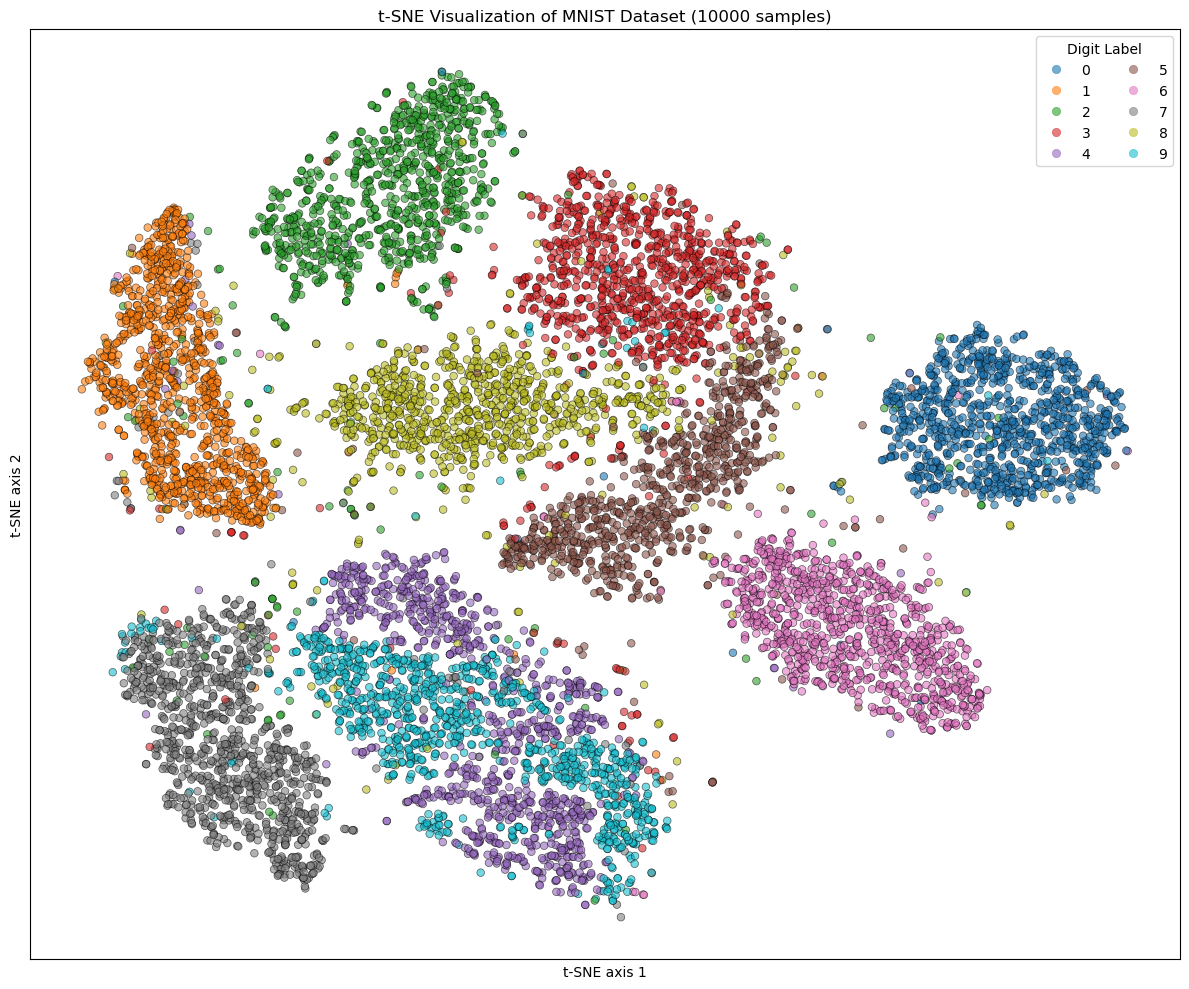

In [6]:
# t-SNE visualization of MNIST dataset
from sklearn.manifold import TSNE

# Use a subset of training data for faster computation
subset_size = 10000
subset_indices = rs.choice(len(x_train), size=min(subset_size, len(x_train)), replace=False)

X_subset = x_train[subset_indices].numpy()
y_subset = y_train[subset_indices].argmax(axis=1).numpy()

# Flatten images from 28x28 to 784
X_flat = X_subset.reshape(X_subset.shape[0], -1)

print("Computing t-SNE...")
tsne = TSNE(n_components=2, random_state=SEED, perplexity=50, verbose=1)
X_tsne = tsne.fit_transform(X_flat)

print(f"t-SNE embedding shape: {X_tsne.shape}")

# Create visualization
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_subset, cmap='tab10', alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
ax.set_xlabel('t-SNE axis 1')
ax.set_ylabel('t-SNE axis 2')
ax.set_xticks([]) # disable axis ticks since they are not informative in t-SNE
ax.set_yticks([])
ax.set_title(f't-SNE Visualization of MNIST Dataset ({subset_size} samples)')
handles, labels = scatter.legend_elements()
ax.legend(handles, labels, title='Digit Label', ncol=2)
plt.tight_layout()
plt.show()
fig.savefig(SAVE_DIR / "tSNE.png", dpi=300, bbox_inches="tight")

Digits 4 and 9 form a unique cluster, which suggests that a future anomaly detection system might struggle to differentiate between digits 4 and 9. We are **not** going to use this information for fine-tuning in order to keep the test set independent from the system and ensure valid final evaluation results.

## PCA

PCA allows for extraction of eigenvectors of the data's covariance matrix. We use that to explore the rate of drop in importance of principal components (PC) and properties of the most important components.

In [7]:
from sklearn.decomposition import PCA

# Apply PCA on train_rest images (flattened 28x28 -> 784 features).
train_rest_x = train_rest[0].numpy()
train_rest_y = train_rest[1]

# Keep 95% of variance to choose dimensionality automatically.
pca = PCA(n_components=50, svd_solver="full")
train_rest_x_pca = pca.fit_transform(train_rest_x)

# Keep labels unchanged and store reduced features as a torch tensor.
train_rest_pca = (torch.from_numpy(train_rest_x_pca).float(), train_rest_y)

print(f"Original train_rest shape: {train_rest_x.shape}")
print(f"PCA train_rest shape: {train_rest_pca[0].shape}")
print(f"Number of PCA components: {pca.n_components_}")
print(f"Explained variance ratio sum: {pca.explained_variance_ratio_.sum():.4f}")

Original train_rest shape: (44304, 784)
PCA train_rest shape: torch.Size([44304, 50])
Number of PCA components: 50
Explained variance ratio sum: 0.8316


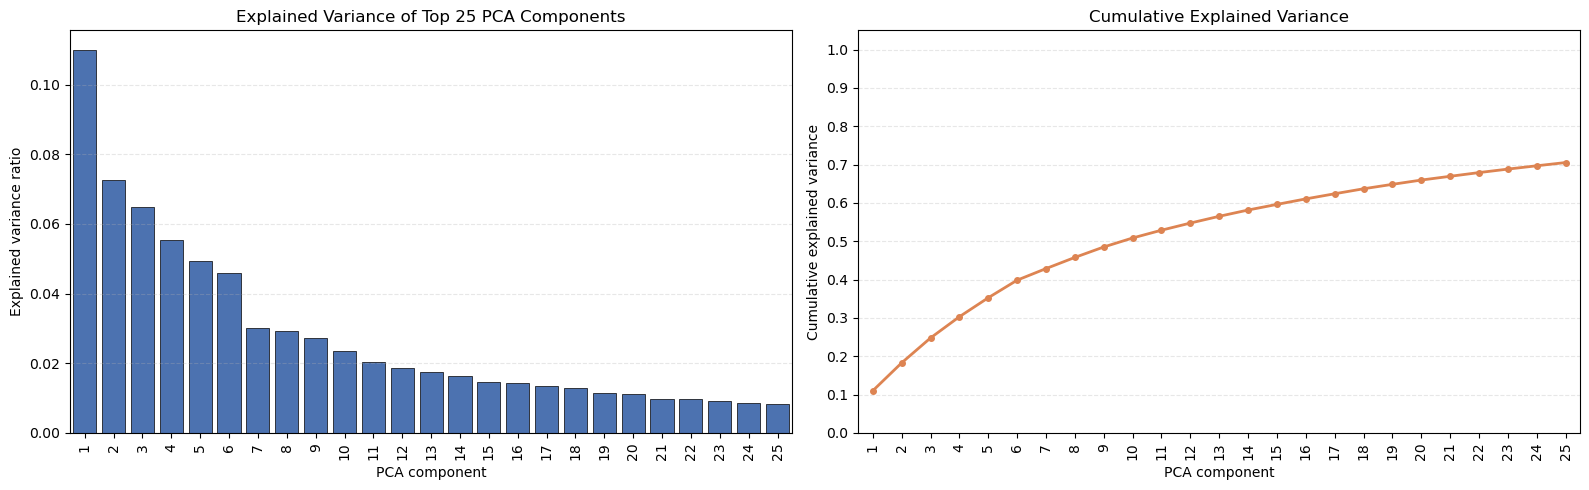

In [8]:
# Plot the variance explained by the top PCA components.
components_to_plot = min(25, len(pca.explained_variance_ratio_))
explained_variance = pca.explained_variance_ratio_[:components_to_plot]
component_ids = np.arange(1, components_to_plot + 1)
cumulative_explained_variance = np.cumsum(explained_variance)

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 5))

ax_left.bar(component_ids, explained_variance, color="#4C72B0", edgecolor="black", linewidth=0.5)
ax_left.set_xlabel("PCA component")
ax_left.set_ylabel("Explained variance ratio")
ax_left.set_title(f"Explained Variance of Top {components_to_plot} PCA Components")
ax_left.set_xticks(component_ids)
ax_left.set_xticklabels(component_ids, rotation=90)
ax_left.set_xlim(0.5, components_to_plot + 0.5)
ax_left.grid(axis="y", linestyle="--", alpha=0.3)

ax_right.plot(component_ids, cumulative_explained_variance, color="#DD8452", marker="o", linewidth=2, markersize=4)
ax_right.set_xlabel("PCA component")
ax_right.set_ylabel("Cumulative explained variance")
ax_right.set_title("Cumulative Explained Variance")
ax_right.set_xticks(component_ids)
ax_right.set_xticklabels(component_ids, rotation=90)
ax_right.set_xlim(0.5, components_to_plot + 0.5)
ax_right.set_ylim(0, 1.05)
ax_right.set_yticks(np.arange(0.0, 1.01, 0.1))
ax_right.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()
fig.savefig(SAVE_DIR / "pca_explained_variance.png", dpi=300, bbox_inches="tight")

Cumulative explained variance predictably follows a logarithmic trend: 10 PCs explain about 50%, and 25 PCs explain about 70%. Since only a few PCs contain most of the data variance, we take a closer look at the most important components.

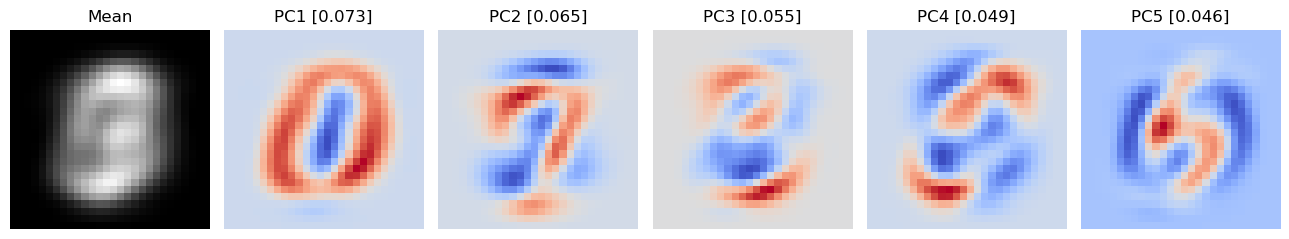

In [9]:
# Show the mean digit, then the top 10 PCA basis images (eigendigits).
top_k = 5
mean_digit = pca.mean_.reshape(28, 28)
components = pca.components_[:top_k]

fig, axes = plt.subplots(1, top_k + 1, figsize=(13, 4))

axes[0].imshow(mean_digit, cmap="gray")
axes[0].set_title("Mean")
axes[0].axis("off")

for idx, component in enumerate(components, start=1):
    eigen_digit = component.reshape(28, 28)
    eigen_min = eigen_digit.min()
    eigen_max = eigen_digit.max()
    if eigen_max > eigen_min:
        eigen_digit = (eigen_digit - eigen_min) / (eigen_max - eigen_min)

    axes[idx].imshow(eigen_digit, cmap="coolwarm")
    axes[idx].set_title(f"PC{idx} [{pca.explained_variance_ratio_[idx]:.3f}]")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()
fig.savefig(SAVE_DIR / "mean_and_top10_eigendigits.png", dpi=300, bbox_inches="tight")

The leftmost image is an "average" digit, which represents the mean of all samples.

We see that PCs represent the most common changes in the data, which is similar to the digits in the dataset: PC1 axis represents a combination of 0 (red) and 1 (blue); PC2 axis represents a combination of 7 (red) and 2 (blue).

In order to visualize explained variance and cluster formations, we scatter images projected onto the first 2 most important components.

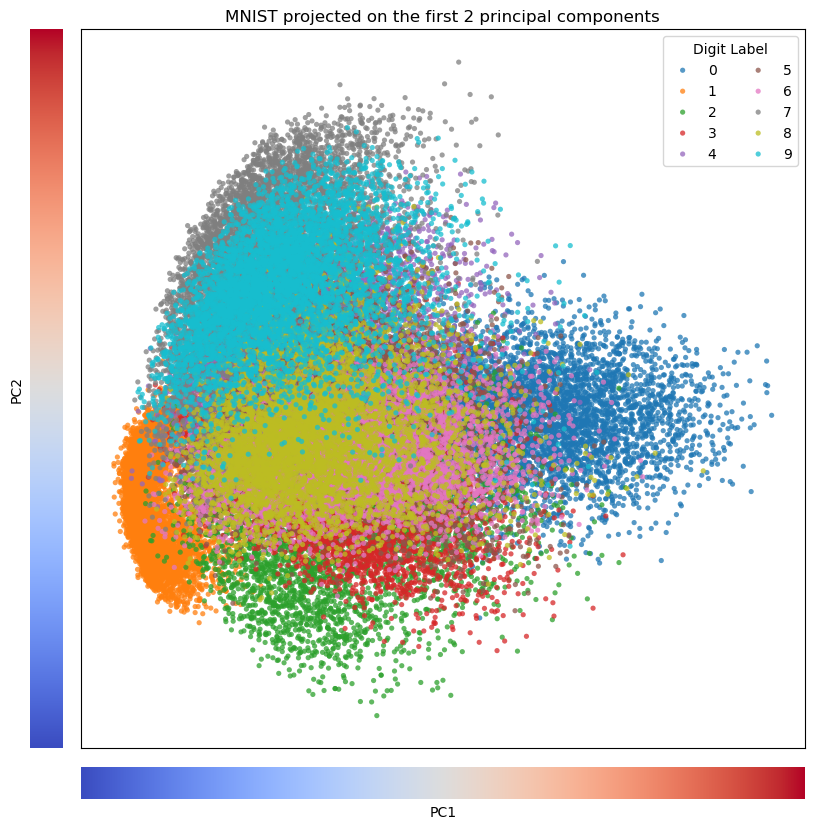

In [10]:
# Project the images onto the first 2 principal components.
x_all = x_train.numpy()
y_all = y_train.argmax(dim=1).numpy()
scores = pca.transform(x_all)[:, :2]

fig = plt.figure(figsize=(10, 10))
grid = fig.add_gridspec(
    2,
    2,
    width_ratios=[0.45, 10],
    height_ratios=[10, 0.45],
    wspace=0.05,
    hspace=0.05,
)

ax_y = fig.add_subplot(grid[0, 0])
ax_scatter = fig.add_subplot(grid[0, 1])
ax_corner = fig.add_subplot(grid[1, 0])
ax_x = fig.add_subplot(grid[1, 1])

digit_colors = plt.cm.tab10(np.arange(10))
for digit, color in enumerate(digit_colors):
    mask = y_all == digit
    ax_scatter.scatter(
        scores[mask, 0],
        scores[mask, 1],
        s=14,
        alpha=0.75,
        color=color,
        label=str(digit),
        edgecolors="none",
    )

ax_scatter.set_title("MNIST projected on the first 2 principal components")
ax_scatter.set_xticks([])
ax_scatter.set_yticks([])
ax_scatter.legend(title="Digit Label", ncol=2)

x_min, x_max = scores[:, 0].min(), scores[:, 0].max()
y_min, y_max = scores[:, 1].min(), scores[:, 1].max()

x_gradient = np.linspace(0, 1, 256).reshape(1, -1)
ax_x.imshow(x_gradient, cmap="coolwarm", aspect="auto", extent=[x_min, x_max, 0, 1])
ax_x.set_xticks([])
ax_x.set_yticks([])
ax_x.set_frame_on(False)
ax_x.set_xlabel("PC1")

y_gradient = np.linspace(0, 1, 256).reshape(-1, 1)
ax_y.imshow(y_gradient, cmap="coolwarm", aspect="auto", extent=[0, 1, y_min, y_max], origin="lower")
ax_y.set_xticks([])
ax_y.set_yticks([])
ax_y.set_frame_on(False)
ax_y.set_ylabel("PC2")

ax_corner.axis("off")

plt.show()
fig.savefig(SAVE_DIR / "pca_pc1_pc2_scatter_with_gray_axes.png", dpi=300, bbox_inches="tight")

Some clusters are compact and well formed with only the first 2 PCA components. To demonstrate the PCA mask structure, we visualize extreme samples for both axes of the PCA space with the mask of the respective component overlaid.

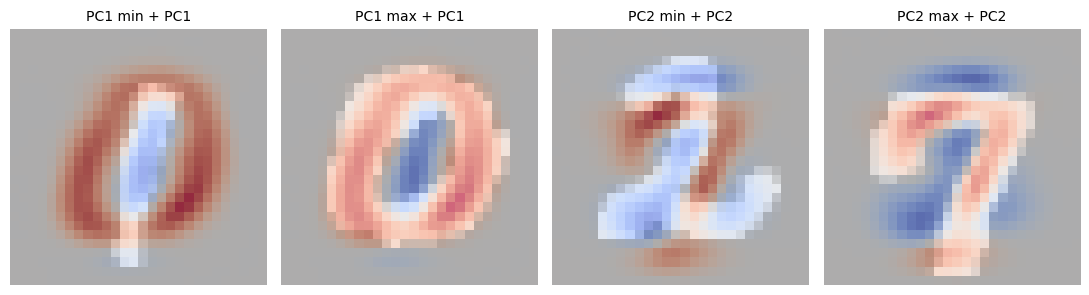

In [11]:
# Show the 4 extreme samples in PCA space, grouped by the matching principal component
pc1_min_index = int(np.argmin(scores[:, 0]))
pc1_max_index = int(np.argmax(scores[:, 0]))
pc2_min_index = int(np.argmin(scores[:, 1]))
pc2_max_index = int(np.argmax(scores[:, 1]))

pc1_basis = pca.components_[0].reshape(28, 28)
pc2_basis = pca.components_[1].reshape(28, 28)

pc1_display = pc1_basis / np.max(np.abs(pc1_basis))
pc2_display = pc2_basis / np.max(np.abs(pc2_basis))

sample_indices = [pc1_min_index, pc1_max_index, pc2_min_index, pc2_max_index]
basis_map = [pc1_display, pc1_display, pc2_display, pc2_display]
titles = ["PC1 min + PC1", "PC1 max + PC1", "PC2 min + PC2", "PC2 max + PC2"]

fig, axes = plt.subplots(1, 4, figsize=(11, 6))

for ax, samp_idx, basis_img, title in zip(axes, sample_indices, basis_map, titles):
    sample_image = x_all[samp_idx].reshape(28, 28)

    ax.imshow(sample_image, cmap="gray", alpha=0.6)
    im = ax.imshow(basis_img, cmap="coolwarm", alpha=0.6, vmin=-1.0, vmax=1.0)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()
fig.savefig(SAVE_DIR / "pca_extreme_samples_pc1_pc2_overlays.png", dpi=300, bbox_inches="tight")

We can clearly see the patterns captured by PC1 and PC2. This suggests high reconstruction accuracy for such samples and might serve as a good baseline for the anomaly detection system.